In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from matplotlib.collections import LineCollection

In [2]:
# Brillouin Zone information
MAX_KX_BZ = 4.0 * np.pi / (3 * np.sqrt(3.0))
MAX_KY_BZ = 2.0 * np.pi / 3.0
R_K_MAX = 4 * np.pi / (3 * np.sqrt(3.0))

In [3]:
def plot_first_bz_boundary(ax = None):
    """
    Plots boundary of the first Brillouin zone for the hexagonal lattice.
    Assumes that the lattice constant a = 1.
    """
    brillouinZoneVertices = np.zeros((7, 2))  # One more to close the polygon

    brillouinZoneVertices[:, 0] = np.array(
        [
            4.0 * np.pi / (3 * np.sqrt(3.0)),
            2.0 * np.pi / (3 * np.sqrt(3.0)),
            -2.0 * np.pi / (3 * np.sqrt(3.0)),
            -4.0 * np.pi / (3 * np.sqrt(3.0)),
            -2.0 * np.pi / (3 * np.sqrt(3.0)),
            2.0 * np.pi / (3 * np.sqrt(3.0)),
            4.0 * np.pi / (3 * np.sqrt(3.0)),
        ]
    )

    brillouinZoneVertices[:, 1] = np.array(
        [
            0.0,
            -2.0 * np.pi / 3.0,
            -2.0 * np.pi / 3.0,
            0.0,
            2.0 * np.pi / 3.0,
            2.0 * np.pi / 3.0,
            0.0,
        ]
    )
    if ax == None:
        ax = plt.gca()
    ax.plot(
        brillouinZoneVertices[:, 0],
        brillouinZoneVertices[:, 1],
        "--",
        color="black",
        linewidth=2,
    )

In [4]:
# Plotting convenience
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["font.sans-serif"] = "Computer Modern Sans serif"
plt.rcParams["font.monospace"] = "Computer Modern Typewriter"
plt.rcParams["axes.titlesize"] = 36
plt.rcParams["axes.labelsize"] = 36
plt.rcParams["xtick.labelsize"] = 32
plt.rcParams["ytick.labelsize"] = 32
plt.rcParams["font.size"] = 32
plt.rcParams["legend.fontsize"] = 32
plt.rcParams["legend.title_fontsize"] = 32
# Optionally, add custom LaTeX preamble
plt.rcParams["text.latex.preamble"] = (
    r"\usepackage{amsmath} \usepackage{amsfonts} \usepackage{amssymb}"
)

# Set rcParams for tighter layout
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.constrained_layout.use"] = False
plt.rcParams["axes.linewidth"] = 1.2

# Set rcParams to show ticks on both left and right sides
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True

plt.rcParams["axes.xmargin"] = 0.01

Lets start with sympy - we could easily define a Hamiltonian within this package

In [5]:
# Defining sympy symbols
k_x, k_y = sp.symbols('k_x k_y', real=True)
a  = sp.symbols('a', real=True, positive=True)
t_pi, t_sigma = sp.symbols('t_pi t_sigma', real=True) #t_I and t_D respectively in Fortran programs
l_soc = sp.symbols('lambda_soc', real=True)
d_tri = sp.symbols('delta_tri', real=True)
t_rashba = sp.symbols('t_rashba', real=True)
mu = sp.symbols('mu', real=True)

In [6]:
# Pauli matrices
s_0 = sp.eye(2)
s_x = sp.Matrix([[0, 1], [1, 0]])
s_y = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s_z = sp.Matrix([[1, 0], [0, -1]])

# Orbital angular momentum matrices in [111] direction (z || [111])
L_x = sp.Matrix([
    [0, 0, sp.I],
    [0, 0, sp.I],
    [-sp.I, -sp.I, 0]
]) / sp.sqrt(2)

L_y = sp.Matrix([
    [0, -2*sp.I, -sp.I],
    [2*sp.I, 0, sp.I],
    [sp.I, -sp.I, 0]
]) / sp.sqrt(6)

L_z = sp.Matrix([
    [0, -sp.I, sp.I],
    [sp.I, 0, -sp.I],
    [-sp.I, sp.I, 0]
]) / sp.sqrt(3)


In [7]:
def build_hermitian_from_upper_triangle(M: sp.Matrix) -> sp.Matrix:
    """
    Builds a Hermitian matrix from its upper triangle.
    The lower triangle is filled with the conjugate transpose of the upper triangle.
    """
    N = M.shape[0]
    H = sp.zeros(N)
    for i in range(N):
        for j in range(i, N):
            H[i, j] = M[i, j]
            H[j, i] = sp.conjugate(M[i, j])
    return H

# Building Hamiltonian
## Kinetic term

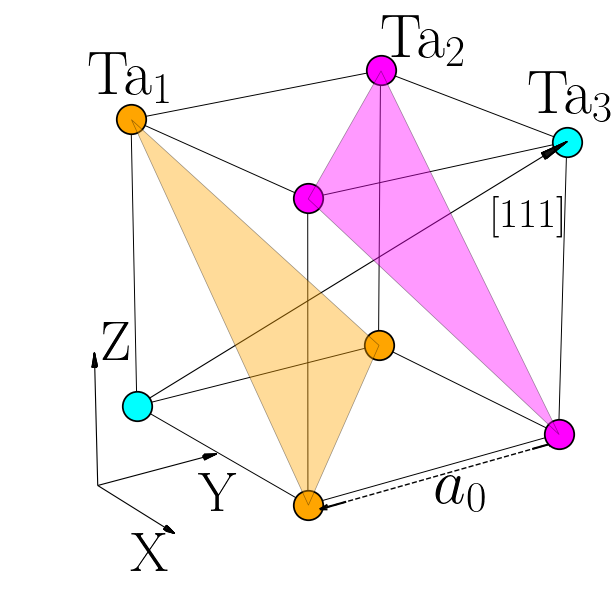
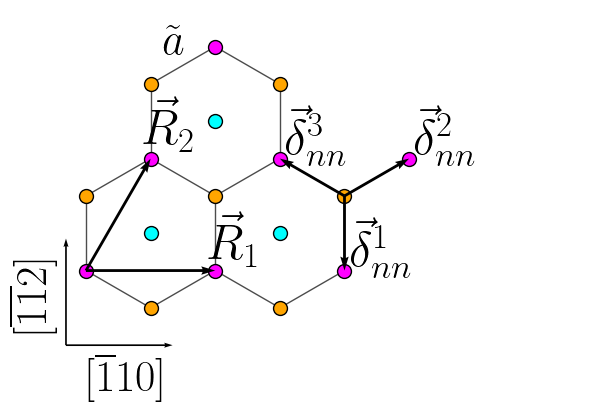

## As you see, the structure at the interface in [111] direction has a honeycomb lattice (taking into account only pink and orange sites).
## We will assume that the superconductivity arises due to attractive interaction between electrons occupying nearest-neighboring sites.

In [8]:
# Vectors connecting nearest neighbors - TODO: add plot of structure
k1 = k_y
k2 = sp.sqrt(3) / 2 * k_x - sp.Rational(1, 2) * k_y
k3 = -sp.sqrt(3) / 2 * k_x - sp.Rational(1, 2) * k_y


eps_yz = -t_sigma * (sp.exp(sp.I * k1) + sp.exp(sp.I * k2)) - t_pi * sp.exp(sp.I * k3)
eps_zx = -t_sigma * (sp.exp(sp.I * k1) + sp.exp(sp.I * k3)) - t_pi * sp.exp(sp.I * k2)
eps_xy = -2 * t_sigma * sp.cos(sp.sqrt(3) / 2 * k_x) * sp.exp(-sp.I / 2 * k_y) - t_pi * sp.exp(sp.I * k_y)

H_intraorbital = sp.Matrix([[eps_yz, 0, 0], [0, eps_zx, 0], [0, 0, eps_xy]])
# Extend to sublatttice basis
H_intraorbital = sp.Matrix(sp.kronecker_product(s_x, H_intraorbital))

# Extend to spin basis
H_intraorbital = sp.Matrix(sp.kronecker_product(s_0, H_intraorbital))
#display(H_intraorbital)

## Interorbital hoppings
This part will be responsible for reducing the symmetry from sixfold-symmetric to threefold-symmetric.

In [9]:
# Compute odd-momentum, interorbital hoppping
xi_yz_zx = -t_rashba * (2 * sp.I * sp.exp(-sp.I * k1 / 2) * sp.sin(sp.sqrt(3) / 2 * k_x))
xi_yz_xy = -t_rashba * (sp.exp(sp.I * k1) - sp.exp(sp.I * k3))
xi_zx_xy = -t_rashba * (sp.exp(sp.I * k1) - sp.exp(sp.I * k2))

H_interorbital = sp.Matrix([[0, xi_yz_zx, xi_yz_xy], [-xi_yz_zx, 0, xi_zx_xy], [-xi_yz_xy, -xi_zx_xy, 0]])
# Extend to sublatttice basis
H_interorbital = sp.Matrix(sp.kronecker_product(s_x, H_interorbital))

# Extend to spin basis
H_interorbital = sp.Matrix(sp.kronecker_product(s_0, H_interorbital))
#display(H_interorbital)

## Trigonal crystal field at the interface

In [10]:
# Compute trigonal field
H_tri = d_tri / 2 * sp.Matrix([
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
])
H_tri = sp.kronecker_product(s_0, sp.kronecker_product(s_0, H_tri))
#display(H_tri)

## Atomic spin-orbit coupling $\vec{L} \cdot \vec{S}$

In [11]:
# Compute atomic L \cdot S coupling
H_SOC = l_soc * (sp.Matrix(sp.kronecker_product(s_z, sp.kronecker_product(s_0, L_z))) +
               sp.Matrix(sp.kronecker_product(s_y, sp.kronecker_product(s_0, L_y))) +
               sp.Matrix(sp.kronecker_product(s_x, sp.kronecker_product(s_0, L_x))))
#display(H_SOC)

## Chemical potential

In [12]:
H_mu = -mu * sp.eye(12)
#display(H_mu)

## Export a callback function that will create our Hamiltonian automatically, based on parameters. This will enable conducting numerical calculations with ease.

In [13]:
from sympy.physics.quantum.dagger import Dagger
#No need to conjugate since H is diagonalized via eigh(), which take only upper triangle
H = H_intraorbital + H_interorbital + H_SOC + H_tri + H_mu
H = build_hermitian_from_upper_triangle(H)
compute_H = sp.lambdify((k_x, k_y, t_sigma, t_pi, l_soc, t_rashba, d_tri, mu), H, modules='numpy', cse=True)

In [14]:
#defining parameters
from dataclasses import dataclass, field
# @dataclass
# class dispersion_parameters:
#     """
#     This dataclass defines parameters for a tight-binding model of transition metal oxide.
#     Default values correspond to the LAO/STO interface.
#     """
#     t_sigma: np.float64 = np.float64(500) #[meV]
#     t_pi: np.float64 = np.float64(40) #[meV]
#     l_soc: np.float64 = np.float64(-10) #[meV]
#     t_rashba: np.float64 = np.float64(5) #[meV]
#     d_tri: np.float64 = np.float64(10) #[meV]
#     mu: np.float64 = np.float64(0.) #[meV]
#     a: np.float64 = np.float64(1.0)

@dataclass
class dispersion_parameters:
    """
    This dataclass defines parameters for a tight-binding model of transition metal oxide.
    All energies are defined in units of t_σ.
    """
    t_sigma: np.float64 = np.float64(1.0) # Energy of sigma-overlap between d orbitals [t_σ]
    t_pi: np.float64 = np.float64(0.08) # Energy of pi-overlap between d orbitals [t_σ]
    l_soc: np.float64 = np.float64(-0.02) # Atomic SOC energy [t_σ]
    t_rashba: np.float64 = np.float64(0.01) # Odd-momentum (p-d hybridization) hopping energy[t_σ]
    d_tri: np.float64 = np.float64(0.02) # Trigonal spitting energy [t_σ]
    mu: np.float64 = np.float64(0.) # Chemical potential [t_σ]
    a: np.float64 = np.float64(1.0) # Lattice constant
    min_energy_kinetics: np.float64 = field(init=False) # Minimum energy estimated from kinetic-only terms of the Hamiltonian

    def __post_init__(self):
        self.min_energy_kinetics = np.float64(-(2 * self.t_sigma + self.t_pi)) #[t_σ]

params = dispersion_parameters() # default values

In [15]:
def calculate_spin_expectation(eigenvectors: np.ndarray) -> tuple:
    """
    Calculate spin expectation values <S_x>, <S_y>, <S_z> for each eigenvector.

    Parameters:
    -----------
    eigenvectors : np.ndarray
        Array of shape (N, N) where each column is an eigenvector.
        First N/2 indices correspond to spin-up, second N/2 to spin-down.

    Returns:
    --------
    spin_x, spin_y, spin_z : np.ndarray
        Arrays of shape (N,) containing expectation values for each eigenvector.
    """
    N = eigenvectors.shape[0]
    n_orb = N // 2
    n_states = eigenvectors.shape[1]

    spin_x = np.zeros(n_states)
    spin_y = np.zeros(n_states)
    spin_z = np.zeros(n_states)

    for i in range(n_states):
        psi = eigenvectors[:, i]
        psi_up = psi[:n_orb]
        psi_down = psi[n_orb:]

        spin_x[i] = 0.5 * (np.vdot(psi_up, psi_down) + np.vdot(psi_down, psi_up)).real
        spin_y[i] = 0.5 * (np.vdot(psi_up, psi_down) - np.vdot(psi_down, psi_up)).imag
        spin_z[i] = 0.5 * (np.vdot(psi_up, psi_up) - np.vdot(psi_down, psi_down)).real

    return spin_x, spin_y, spin_z

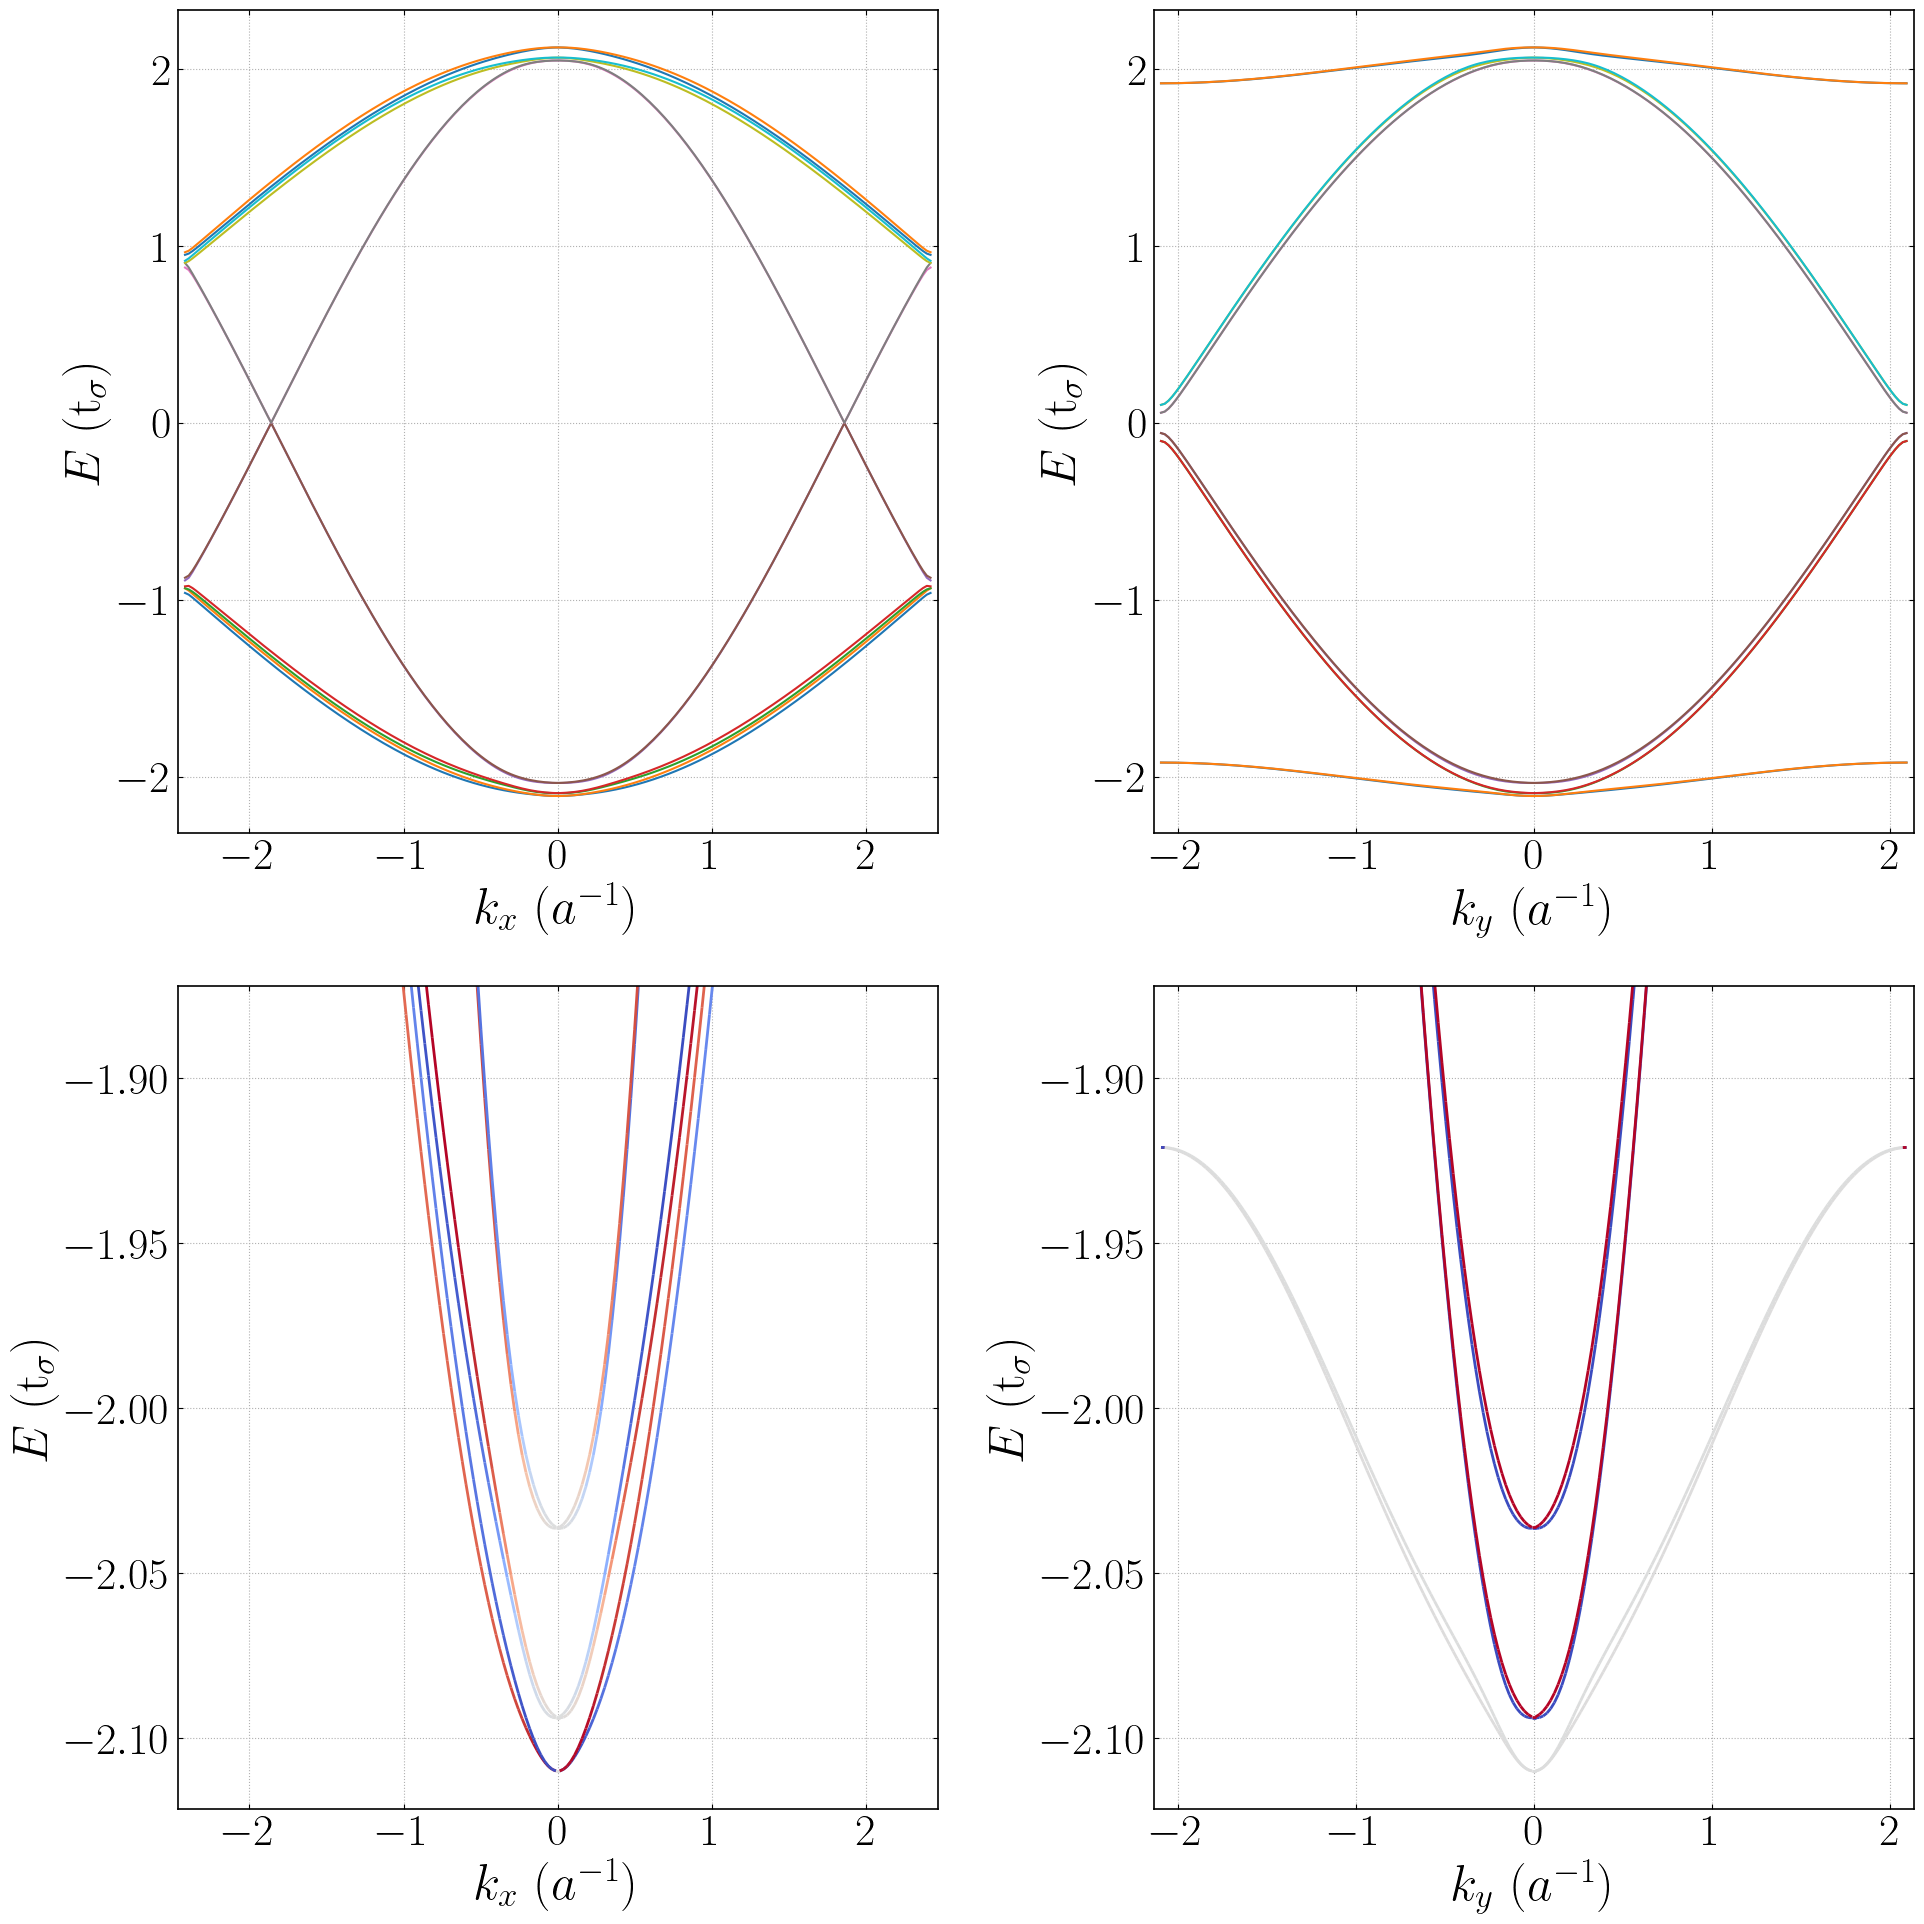

In [16]:
def plot_k_slices(params: dispersion_parameters, ham_dim: int, n_k_points: int = 200):
    """
    Plot energy bands along k_x and k_y directions.

    Parameters:
    -----------
    params : dispersion_parameters
        Parameters for the tight-binding model.
    ham_dim : int
        Dimension of the Hamiltonian matrix.
    n_k_points : int, optional
        Number of points to sample along k_x and k_y directions.
        Default is 200.
    """

    """ ------ Plot along k_x direction (k_y = 0) ------- """
    fig, axes = plt.subplots(2,2, figsize=(20, 20))
    k_x_vals = np.linspace(-MAX_KX_BZ, MAX_KX_BZ, n_k_points)
    Energies = np.zeros((k_x_vals.size, ham_dim))
    S_z = np.zeros((k_x_vals.size, ham_dim))

    # Slice along k_x direction (k_y = 0)
    for i, kx in enumerate(k_x_vals):
        H_k = compute_H(kx, 0, params.t_sigma, params.t_pi, params.l_soc, params.t_rashba, params.d_tri, params.mu)
        evals, evecs = np.linalg.eigh(H_k, UPLO='U')
        Energies[i] = evals
        _, _, S_z[i] = calculate_spin_expectation(evecs)
    axes[0, 0].plot(k_x_vals, Energies)
    axes[0, 0].set_xlabel(r'$k_x$ ($a^{-1}$)')
    axes[0, 0].set_ylabel(r'$E$ ($\text{t}_\sigma$)')
    axes[0, 0].grid(True, linestyle=':')

    # Low energy plot along k_x with spin expectation value coloring
    for band in range(ham_dim):
        points = np.array([k_x_vals, Energies[:, band]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='coolwarm', linewidth=2)
        segmentColors = 0.5 * (S_z[:-1, band] + S_z[1:, band])
        lc.set_array(segmentColors)
        axes[1, 0].add_collection(lc)
        axes[1, 0].autoscale()

    axes[1, 0].set_xlabel(r'$k_x$ ($a^{-1}$)')
    axes[1, 0].set_ylabel(r'$E$ ($\text{t}_\sigma$)')
    axes[1, 0].set_ylim(bottom=1.02 * params.min_energy_kinetics, top = 0.9 * params.min_energy_kinetics)
    axes[1, 0].grid(True, linestyle=':')

    """ ------ Plot along k_y direction (k_x = 0) ------- """
    k_y_vals = np.linspace(-MAX_KY_BZ, MAX_KY_BZ, n_k_points)
    Energies = np.zeros((k_y_vals.size, ham_dim))
    S_z = np.zeros((k_y_vals.size, ham_dim))
    # Slice along k_y direction (k_x = 0)
    for i, ky in enumerate(k_y_vals):
        H_k = compute_H(0, ky, params.t_sigma, params.t_pi, params.l_soc, params.t_rashba, params.d_tri, params.mu)
        evals, evecs = np.linalg.eigh(H_k, UPLO='U')
        Energies[i] = evals
        _, _, S_z[i] = calculate_spin_expectation(evecs)
    axes[0, 1].plot(k_y_vals, Energies)
    axes[0, 1].set_xlabel(r'$k_y$ ($a^{-1}$)')
    axes[0, 1].set_ylabel(r'$E$ ($\text{t}_\sigma$)')
    axes[0, 1].grid(True, linestyle=':')

    # Low energy plot along k_y with spin expectation value coloring
    for band in range(ham_dim):
        points = np.array([k_y_vals, Energies[:, band]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap='coolwarm', linewidth=2)
        segmentColors = 0.5 * (S_z[:-1, band] + S_z[1:, band])
        lc.set_array(segmentColors)
        axes[1, 1].add_collection(lc)
        axes[1, 1].autoscale()

    axes[1, 1].set_xlabel(r'$k_y$ ($a^{-1}$)')
    axes[1, 1].set_ylabel(r'$E$ ($\text{t}_\sigma$)')
    axes[1, 1].set_ylim(bottom=1.02 * params.min_energy_kinetics, top = 0.9 * params.min_energy_kinetics)
    axes[1, 1].grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

plot_k_slices(params, 12)


As you can see in the pictures, we are able to generate a complex band structure for LAO/STO in [111] crystallographic direction.
Please note, that it is highly anisotropic, with a heavy band along Y direction (the band that has its maximum around -960 meV).
Apart from that you can see the impact of Rashba-like spin-orbit coupling that shifts the bands depending on spin (note the splitting between red and blue lines that are degenerate at k = 0 point).

/tmp/ipykernel_3818362/3887252515.py:68: RuntimeWarning: Mean of empty slice.
  kx_center, ky_center = vertices[:,0].mean(), vertices[:,1].mean()
/home/czarnecki/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


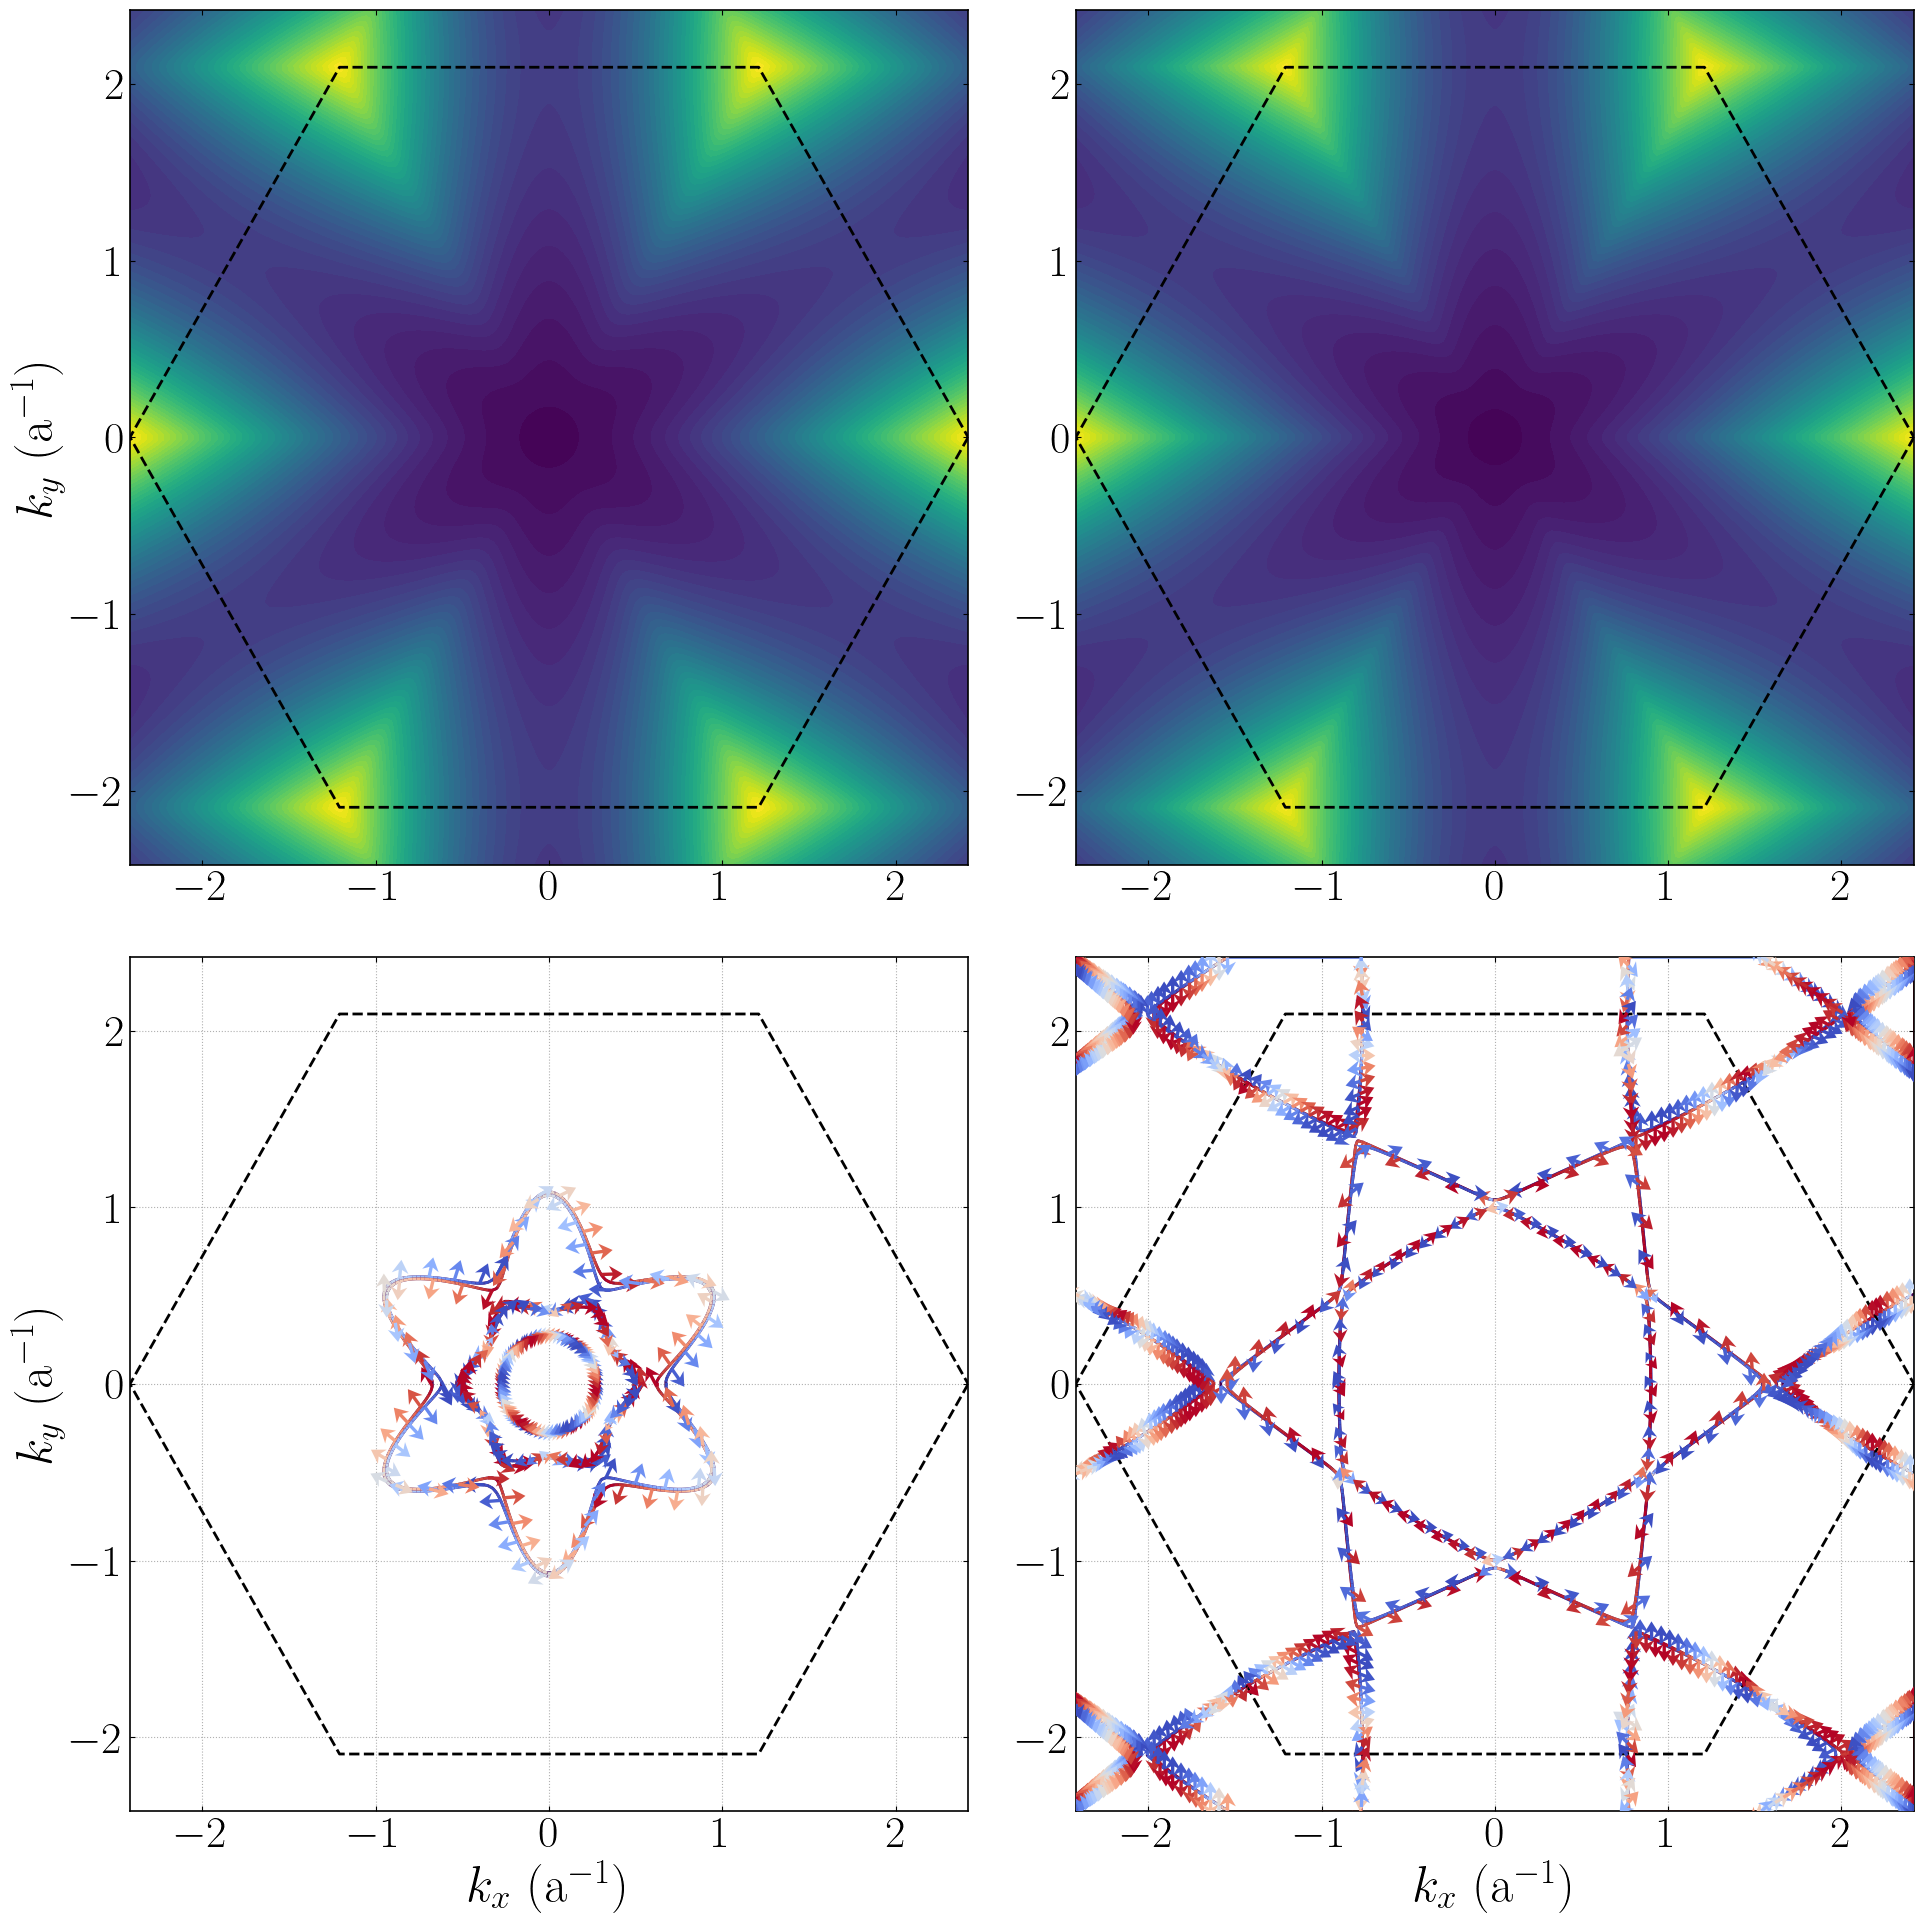

In [17]:
from scipy.interpolate import RegularGridInterpolator

def plot_dispersion(params: dispersion_parameters, ham_dim: int, n_k_points: int = 200, Fermi_levels: tuple = (-2, -1.5)):
    """
    This function plots the dispersion relation for a given set of parameters.
    It generates two kinds of plots - contourf plots of the energy bands for two lowest bands,
    and contour plots of the Fermi surfaces with spin expectation value coloring.

    Parameters:
    -----------
    params : dispersion_parameters
        Parameters for the tight-binding model.
    ham_dim : int
        Dimension of the Hamiltonian matrix.
    n_k_points : int, optional
        Number of k-points to sample in the Brillouin zone.
        Default is 200.
    Fermi_levels : tuple, optional
        Tuple of two Fermi levels to plot the Fermi surfaces.
        Default is (-1000, -950) meV.
    """
    k_x_vals = np.linspace(-MAX_KX_BZ, MAX_KX_BZ, n_k_points)
    k_y_vals = np.linspace(-MAX_KX_BZ, MAX_KX_BZ, n_k_points)
    KX, KY = np.meshgrid(k_x_vals, k_y_vals, indexing='ij') # Swap to indexing='ij' for correct orientation
    Energies = np.zeros((n_k_points, n_k_points, ham_dim))
    S_x = np.zeros((n_k_points, n_k_points, ham_dim))
    S_y = np.zeros((n_k_points, n_k_points, ham_dim))
    S_z = np.zeros((n_k_points, n_k_points, ham_dim))
    for i, kx in enumerate(k_x_vals):
        for j, ky in enumerate(k_y_vals):
            H_k = compute_H(kx, ky, params.t_sigma, params.t_pi, params.l_soc, params.t_rashba, params.d_tri, params.mu)
            evals, evecs = np.linalg.eigh(H_k, UPLO='U')
            Energies[i, j] = evals
            S_x[i, j], S_y[i, j], S_z[i, j] = calculate_spin_expectation(evecs)
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    # First row: contourf plots
    axes[0, 0].contourf(KX, KY, Energies[:, :, 0], levels=50)
    axes[0, 0].set_ylabel(r'$k_y$ (a$^{-1}$)')
    plot_first_bz_boundary(axes[0, 0])
    axes[0, 1].contourf(KX, KY, Energies[:, :, 1], levels=50)
    plot_first_bz_boundary(axes[0, 1])

    # Second row: contour plots for each Fermi level
    for idx, level in enumerate(Fermi_levels):
        ax = axes[1, idx]
        for band in range(ham_dim):
            cs = ax.contour(KX, KY, Energies[:, :, band], levels=[level], linewidths=2)
            for vertices in cs.allsegs[0]:
                # Interpolate spin expectation values along the contour
                interp_S_x = RegularGridInterpolator((k_x_vals, k_y_vals),
                                                     S_x[:, :, band],
                                                     bounds_error=False,
                                                     fill_value=np.nan)
                interp_S_y = RegularGridInterpolator((k_x_vals, k_y_vals),
                                                     S_y[:, :, band],
                                                     bounds_error=False,
                                                     fill_value=np.nan)
                interp_S_z = RegularGridInterpolator((k_x_vals, k_y_vals),
                                                     S_z[:, :, band],
                                                     bounds_error=False,
                                                     fill_value=np.nan)

                interpolated_S_x = interp_S_x(vertices)
                interpolated_S_y = interp_S_y(vertices)
                interpolated_S_z = interp_S_z(vertices)

                kx_center, ky_center = vertices[:,0].mean(), vertices[:,1].mean()
                phases = np.arctan2(vertices[:,1] - ky_center, vertices[:,0] - kx_center)
                order = np.argsort(phases)

                vertices = vertices[order]
                interpolated_S_z = interpolated_S_z[order]

                segments = np.stack([vertices[:-1], vertices[1:]], axis=1)
                lc = LineCollection(segments, cmap='coolwarm', linewidth=2)
                lc.set_array(interpolated_S_z[:-1])
                lc.set_linewidth(2)
                ax.add_collection(lc)

                kx_c = vertices[:,0]
                ky_c = vertices[:,1]
                step = max(len(vertices) // 50, 1)
                kx_q = kx_c[::step]
                ky_q = ky_c[::step]
                Sx_q = interpolated_S_x[::step]
                Sy_q = interpolated_S_y[::step]
                Sz_q = interpolated_S_z[::step]
                ax.quiver(
                    kx_q, ky_q,
                    Sx_q, Sy_q,
                    Sz_q,                 # used for color
                    cmap="coolwarm",
                    scale=4,
                    scale_units="xy",
                    width=0.004,
                    headwidth=5,
                    headlength=4,
                    headaxislength=3,
                    zorder=3
                )
            ax.grid(True, linestyle=':')
            ax.set_xlabel(r'$k_x$ (a$^{-1}$)')
        plot_first_bz_boundary(ax)

    axes[1, 0].set_ylabel(r'$k_y$ (a$^{-1}$)')
    plt.tight_layout()
    plt.show()
plot_dispersion(params, 12) #Lets collect the Fermi contours for given Fermi levels

Even though the energies are sixfold-symmetric and could indicate that the Hamiltonian belongs to the $C_{6v}$ point group,
however, a closer look at the spin structure reveals reduction of the symmetry $C_{6v} \rightarrow C_{3v}$.
Convince yourself that it is indee true by rotating the Fermi surface by $\frac{\pi}{3}$ and $\frac{2\pi}{3}$
and check under which rotation the picture is invariant (mind the arrows!).

The invariance condition can also be checked by constructing an operator $U$, representing a symmetry operation
and checking that $U^\dag H U = H$.


# Group theoretical approach to superconducting order parameter

In [18]:
%load_ext autoreload
%autoreload 2
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.append('/home/czarnecki/LAO-STO/GroupTheory')
from GroupGeneratorsClass import C3vGenerator
from SymbolicSymmetryProjectorClass import SymbolicSymmetryProjectorClass
from sympy.physics.quantum import TensorProduct
from sympy import latex
from IPython.display import Math, display

As we now know that the Hamiltonian is invariant under operations of $C_{3v}$ point group,
we can make a step further and say that the solutions have to stay within an $irreducible ~representation$ (IR)
of this point group. Please note that this not necessarily mean that all solutions are symmetric with respect
to all operations i.e. $C_3$ rotation. As an example, recall solutions of Sch\"odinger equation of a hydrogen atom.
Even though the Hamiltonian is spherically symmetric, the solutions can break this symmetry (p-, d- orbitals).

To find the IRs, we will use projections method [3].

First of all, we have to find how symmetry operations $g \in C_{3v}$ will act on different degrees of freedom in our Hamiltonian
and propose matrix representations of those $R(g)$.
You can see in the case of nearest neighbors and vectors $\vec{\delta}_{nn}$ that those operations
only permute the nearest neighbors, so we will write down appropriate permutation matrices.

Then, we will compute projection operators and extract their eigenvectors that have eigenvalue $\lambda = 1$.
The number of such eigenvectors is called $multiplicity$ of an IR. Given that, the solution belonging to an IR $\xi$
can be expressed as a linear combinations of those eigenvectors:
$| \Gamma \rangle = \sum_{n}^{N_{\xi}} a_{n}^{(\xi)} |f_{n}^{(\xi)} \rangle$

[3] https://www.cond-mat.de/events/correl20/manuscripts/senechal.pdf

In [19]:
#Generators

# Nearest neighbors subspace
c3_neigh = sp.Matrix([[0, 1, 0],
                      [0, 0, 1],
                      [1, 0, 0]])
s_v1_neigh = sp.Matrix([[0, 0, 1],
                        [0, 1, 0],
                        [1, 0, 0]])

# Orbital subspace
c3_orb = sp.Matrix([[0,1,0],
                    [0,0,1],
                    [1,0,0]])
s_v1_orb = sp.Matrix([[0,1,0],
                      [1,0,0],
                      [0,0,1]])

# Spin subspace
c3_spin = sp.Matrix([[1, 0, 0, 0],
                     [0, sp.cos(sp.pi * 2 / 3), -sp.sin(sp.pi * 2 / 3), 0],
                     [0, sp.sin(sp.pi * 2 / 3), sp.cos(sp.pi * 2 / 3), 0],
                     [0, 0, 0, 1]])
s_v1_spin = sp.Matrix([[1, 0, 0, 0],
                       [0, sp.Rational(1,2), sp.sqrt(3)/2, 0],
                       [0, sp.sqrt(3)/2, -sp.Rational(1,2), 0],
                       [0, 0, 0, 1]])


# Sublattice degree of freedom is excluded on purpose.
# This is because in the C_3v group no operation mixes sublattices, so that all operators
# in the sublattice space are unitary. This only extends the basis and generates (spare)
# solutions to the eigenproblem.
# We take care of the number of sublattices later on when constructing the pairing matrix.

# Action on all degrees of freedom could be represented as
# tensor product of symmetry operations in all submodules.
c3_total = TensorProduct(c3_spin, c3_orb, c3_neigh)
s_v1_total = TensorProduct(s_v1_spin, s_v1_orb, s_v1_neigh)

c3vGroup = C3vGenerator(c3_total, s_v1_total)

symmetryResolver = SymbolicSymmetryProjectorClass(c3vGroup.irrepsTuple,
                                                         c3vGroup.conjugacyClassesTuple,
                                                         c3vGroup.chiTabDict,
                                                         c3vGroup.representationDim)
projectionMatrices = symmetryResolver.getProjectionOperators(c3vGroup.getOperationsDict())
multiplicities = symmetryResolver.getMultiplicities(c3vGroup.getOperationsDict())
for irrep in multiplicities:
  display(f"N({irrep}) = {multiplicities[irrep]}")
eigenproblem = symmetryResolver.getDiagonalizedProjections(projectionMatrices)
eigenproblem = symmetryResolver.filterOutProjections(eigenproblem)


'N(A_1) = 7'

'N(A_2) = 5'

'N(E) = 12'

In [20]:
## Check C3 invariance of the normal-state Hamiltonian
c3_spinor = sp.exp(-sp.I * sp.Rational(2,6) * sp.pi) * s_z
U_c3 = TensorProduct(c3_spinor, sp.eye(2), c3_orb)

kp_x, kp_y = sp.symbols('kp_x kp_y', real=True)

# display(H)
# H_basis_transformed = sp.simplify(Dagger(U_c3) * H * U_c3)
# display(H_basis_transformed)

In [21]:
def get_matrix_indices(projectionIndex: int) -> tuple[int, int]:
  """
  Returns indices of matrix elements in 12x12 matrix for given projection index.

  Parameters:
  -----------
  projectionIndex : int
      Index in the order parameter matrix.
      Assuming no sublattice degree of freedom in included.

  Returns:
  --------
  spin : int
      Spin index in basis (sigma_0, sigma_x, sigma_y, sigma_z).
  orbital : int
      Orbital index in basis (d_yz, d_zx, d_xy).
  """
  spin = projectionIndex // 3
  orbital = projectionIndex % 3

  return spin, orbital

# Define matrices that represent intraorbital coupling for a given index
# in the irreducible representation eigenvector.
orb_yz = sp.Matrix([[1, 0, 0],
                    [0, 0, 0],
                    [0, 0, 0]])
orb_zx = sp.Matrix([[0, 0, 0],
                    [0, 1, 0],
                    [0, 0, 0]])
orb_xy = sp.Matrix([[0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 1]])

# Since we currently work only in the nearest-neighbors hopping,
# we couple two different sublattices.
# The matrix below represents the coupling between two sublattices in the order of projection vector.
sublat_hop_12 = sp.Matrix([[0, 1],
                           [0, 0]])

# Bloch functions e^{i * k * r} for three nearest neighbors.
# It represent hopping from sublattice A -> B.
# The inverse hopping is generated based on antisymmetry of the gap matrix.
basis_functions_12 = sp.Matrix([sp.exp(sp.I * k3), sp.exp(sp.I * k2), sp.exp(sp.I * k1)])

# Define mapping between projection indices and matrices in the orbital and spin space.
orb_couplings = [orb_yz, orb_zx, orb_xy]
spin_parts = [s_0, s_x, s_y, s_z]

pairing_matrices_ir_dict: dict[str, list[sp.Matrix]] = {}
for irrep in c3vGroup.irrepsTuple:
  # Second index is zero, as we are left only with single eigenvalue == 1 after filtering out the others.
  ir_duplicate_count = 0
  deltas_ir = []
  for proj_eigvec in eigenproblem[irrep][0][2]:
    proj_eigvec = proj_eigvec.reshape(12, 3) # each row represents three nearest neighbors in a given sublattice.
    delta_k = sp.zeros(12, 12)

    sublat_idx_1_detected = False
    for i in range(len(proj_eigvec[:, 0])):
      spin, orbital = get_matrix_indices(i)

      elem_k_space = proj_eigvec[i, :].dot(basis_functions_12)
      elem_matrix = TensorProduct(-sp.I * s_y * spin_parts[spin], sublat_hop_12, orb_couplings[orbital])
      elem_matrix *= elem_k_space

      delta_k += elem_matrix

    # Antisymmetrize the gap matrix
    # Note that apart from hopping from A -> B, we also have hopping from B -> A.
    # The relation between A->B and B->A hopping is determined by antisymmetry condition of the gap matrix.
    delta_minus_k = delta_k
    delta_minus_k = delta_minus_k.subs(k_x, -k_x)
    delta_minus_k = delta_minus_k.subs(k_y, -k_y)

    delta_anitsymmetrized = (delta_k - delta_minus_k.T)

    deltas_ir.append(delta_anitsymmetrized)
    # Check fermionic antisymmetry
  print(f"Number of deltas for irrep {irrep}: {len(deltas_ir)}")
  pairing_matrices_ir_dict[irrep] = deltas_ir


Number of deltas for irrep A_1: 7
Number of deltas for irrep A_2: 5
Number of deltas for irrep E: 24


The matrix that includes coupling between electrons and holes can be expressed as

$\mathcal{H} = \begin{pmatrix}  H(k) & \Gamma(k) \\ \Gamma(k)^\dag & -H(-k)^T \end{pmatrix}$

What we have done so far, was determining how the order parameter $\Gamma$ can look like.

You can inspect what are the possible solutions by uncommenting the code below.

In [22]:
# This produces a lot of matrices, but please uncomment this
# to see how the pairing matrices look like for each irrep.

# for irrep in c3vGroup.irrepsTuple:
#   print(f"Pairing matrices for irrep {irrep}:")
#   for n, matrix in enumerate(pairing_matrices_ir_dict[irrep]):
#     print(f"N = {n}")
#     display(matrix)


Lets move to numerical calculations once again

In [23]:
nambu_hamiltonian_callbacks: dict = {}

for irrep in c3vGroup.irrepsTuple:
  pairing_matrices = pairing_matrices_ir_dict[irrep]
  coeffs_symbols = [sp.Symbol(f"xi_{i}", complex=True) for i in range(len(pairing_matrices))]
  gamma_k: sp.Matrix = sp.zeros(12, 12)
  for i in range(len(pairing_matrices)):
    gamma_k += coeffs_symbols[i] * pairing_matrices[i]

  H_k = H
  H_minus_k = H_k.subs(k_x, -k_x)
  H_minus_k = H_minus_k.subs(k_y, -k_y)
  H_minus_k = H_minus_k.T
  H_minus_k = -H_minus_k
  H_nambu = sp.Rational(1,2) * sp.BlockMatrix([[H_k, gamma_k], [sp.conjugate(gamma_k.T), H_minus_k]])
  H_nambu = build_hermitian_from_upper_triangle(H_nambu)
  # print(f"Hamiltionian for irrep {irrep}:")
  # display(H_nambu)
  # Assigning a callback that will build the Nambu Hamiltonian for each irrep
  nambu_hamiltonian_callbacks[irrep] = sp.lambdify((k_x, k_y, t_sigma, t_pi, l_soc, t_rashba, d_tri, mu, *coeffs_symbols), H_nambu, modules='numpy', cse=True)


In [24]:
from tqdm import tqdm
import numba as nb

@nb.njit(fastmath=True)
def accumulate_dos(DOS: np.ndarray, Energies: np.ndarray, eigvals: np.ndarray, zeta: np.float64, r_k: np.float64):
  """
  Accumulates density of states for given energies and eigenvalues
  defined in polar coordinates (r_k, phi_k) in the Brillouin zone, which
  results in the multiplication by Jacobia r_k.
  The DOS is accumulated using Lorentzian broadening with width zeta.

  Parameters
  ----------
  DOS : np.ndarray
      The density of states matrix.
      Updated in place with contributions from given eigenvalues.
  Energies : np.ndarray
      The energy grid for which the DOS is computed.
  eigvals : np.ndarray
      The eigenvalues.
  zeta : float
      The width of the Lorentzian broadening.

  """

  inv_pi = 1.0 / np.pi
  z2 = zeta * zeta
  N_E = Energies.size
  dE = Energies[1] - Energies[0]
  E0 = Energies[0]

  window = 5.0 * zeta

  for n in range(eigvals.size):
    E = eigvals[n]

    # Compute index window
    i_min = int((E - window - E0) / dE)
    i_max = int((E + window - E0) / dE)
    if i_min < 0:
      i_min = 0
    if i_max > N_E:
      i_max = N_E

    for i in range(i_min, i_max):
      d = Energies[i] - E
      dos_incr = zeta * inv_pi / (d*d + z2)
      DOS[i, n] += dos_incr * r_k # Update DOS with Jacobian factor r_k for polar coordinates

def calculate_dos_normal_state(params: dispersion_parameters,
                               E_min: np.float64,
                               E_max: np.float64,
                               dE: np.float64,
                               zeta: np.float64,
                               n_k_points: int) -> tuple[np.ndarray, np.ndarray]:
  """
  Calculates density of states in the normal state by integrating over the Brillouin zone in polar coordinates.
  The Brillouin zone is divided into 6 triangles, and integration is performed in polar coordinates (r_k, phi_k) within each triangle.
  The DOS is accumulated using Lorentzian broadening with width zeta.

  Parameters
  ----------
  params : dispersion_parameters
      Parameters for the tight-binding model.
  E_min : float
      Minimum energy for DOS calculation.
  E_max : float
      Maximum energy for DOS calculation.
  dE : float
      Energy step for DOS calculation.
  zeta : float
      Width of the Lorentzian broadening.
  n_k_points : int
      Number of k-points to sample in each triangle of the Brillouin zone.

  Returns
  ----------
  Energies : np.ndarray
      Energy grid for which the DOS is computed.
  DOS : np.ndarray
      Density of states matrix.
  """
  Hamiltonian = compute_H(0,
                          0,
                          params.t_sigma,
                          params.t_pi,
                          params.l_soc,
                          params.t_rashba,
                          params.d_tri,
                          params.mu,
                        )
  ham_dim = len(Hamiltonian)
  Energies = np.arange(E_min, E_max, dE) # Prepare energy grid for DOS calculation
  DOS = np.zeros((len(Energies), ham_dim)) # Initialize DOS array

  for n_triangle in range(6):
    print(f"Triangle {n_triangle + 1} / {6}")
    phi_min = n_triangle * np.pi / 3
    phi_max = (n_triangle + 1) * np.pi / 3
    d_phi = (phi_max - phi_min) / n_k_points
    for i_phi in tqdm(range(n_k_points)):
      phi_k = phi_min + i_phi * d_phi
      phi_k_relative_to_triangle_boundary = np.mod(phi_k, np.pi / 3)
      r_max = R_K_MAX * np.sqrt(3.0) / (2 * np.cos(phi_k_relative_to_triangle_boundary - np.pi/6))

      for j_r in range(n_k_points):
        d_r = r_max / n_k_points
        r_k = j_r * d_r

        # Transform polar coordinates (r_k, phi_k) to Cartesian coordinates (k_x, k_y)
        k_x = r_k * np.cos(phi_k)
        k_y = r_k * np.sin(phi_k)

        Hamiltonian = compute_H(k_x,
                                k_y,
                                params.t_sigma,
                                params.t_pi,
                                params.l_soc,
                                params.t_rashba,
                                params.d_tri,
                                params.mu,
                              )
        eigvals = np.linalg.eigvalsh(Hamiltonian, UPLO='U')
        accumulate_dos(DOS, Energies, eigvals, zeta, r_k)

  return Energies, DOS

In [25]:
params = dispersion_parameters() # default values
min_energy: np.float64 = np.float64(1.02 * params.min_energy_kinetics)
max_energy: np.float64 = np.float64(0.9 * params.min_energy_kinetics)
n_steps: np.float64 = np.float64(1e3)
dE: np.float64 = (max_energy - min_energy) / n_steps
Energies, DOS = calculate_dos_normal_state(params, min_energy, max_energy, dE, 5*dE, 400)

Triangle 1 / 6


100%|██████████| 400/400 [00:06<00:00, 66.41it/s]


Triangle 2 / 6


100%|██████████| 400/400 [00:05<00:00, 69.36it/s]


Triangle 3 / 6


...

100%|██████████| 400/400 [00:05<00:00, 69.39it/s]


Triangle 5 / 6


100%|██████████| 400/400 [00:05<00:00, 69.58it/s]


Triangle 6 / 6


100%|██████████| 400/400 [00:05<00:00, 69.67it/s]


<Axes: xlabel='E ($\\text{t}_\\sigma$)', ylabel='DOS'>

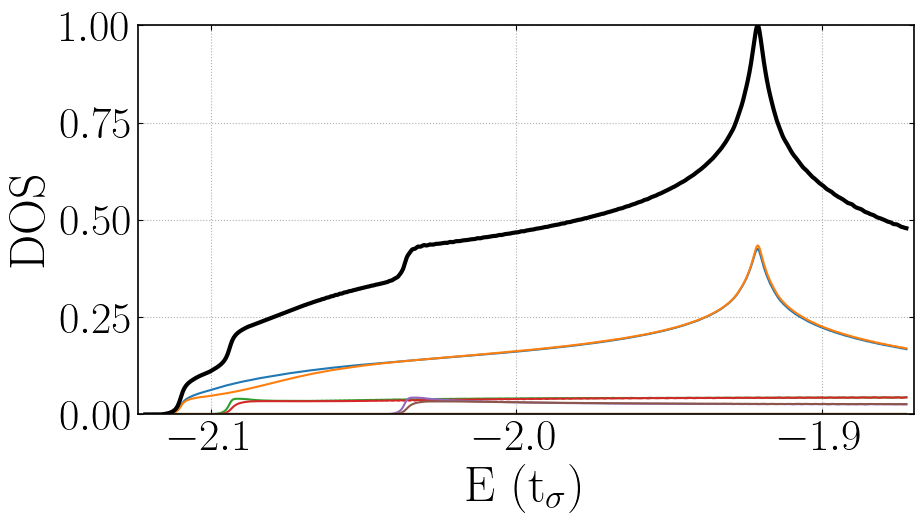

In [26]:
import matplotlib.ticker as ticker
def plot_dos(Energies: np.ndarray, DOS: np.ndarray, ax=None):
  """
  Plots the density of states (DOS) as a function of energy.
  Thick black line represents the total DOS, while colored lines represent contributions from individual bands.
  The DOS is normalized to the maximum value of the total DOS for better visualization.

  Parameters
  ----------
  Energies : np.ndarray
      Energy grid for which the DOS is computed.
  DOS : np.ndarray
      Density of states matrix.
  ax : matplotlib.axes.Axes, optional
      The axes object to plot on. If None, a new figure and axes are created.
  """

  if ax == None:
    fig, ax = plt.subplots(figsize=(10, 6))
  dos_normalization = np.max(np.sum(DOS, axis=1))
  ax.plot(Energies, DOS / dos_normalization)
  ax.plot(Energies, np.sum(DOS, axis=1) / dos_normalization, color='black', linewidth=3)
  ax.set_xlabel(r"E ($\text{t}_\sigma$)")
  ax.set_ylabel("DOS")
  ax.set_ylim(bottom=0, top=1.0)
  ax.yaxis.set_major_locator(ticker.LinearLocator(5))
  ax.grid(True, linestyle=':')
  return ax

plot_dos(Energies, DOS)

Eventually, we would like to see how different IRs change the directionality of the superconducting gap.

Introduction of superconductivity should open a gap at the Fermi level, compared to the DOS in the normal state presented above.

It also has an impact on density of states (DOS) that could be measured in transport measurements

and could account for a directionally-resolved detection.

For a given wavevector, the smaller the superconducting gap, the smaller energy an incoming particles

has to deposit to detect it. This means that our sensitivity grows as the gap shrinks.

In [27]:
def calculate_sc_gap(params: dispersion_parameters, irrep: str, ir_coeffs: np.ndarray, n_k_points: int=200, dE: np.float64=np.float64(1)) -> dict:
    """
    Plots the superconducting gap as a function of momentum for a given irrep and coefficients.
    The gap is calculated on a grid in speherical coordinates in the Brillouin zone and plotted using a line collection
    with colors representing the gap magnitude.

    Parameters
    ----------
    params : dispersion_parameters
        Parameters for the tight-binding model.
    irrep : str
        Irrep name to plot the gap for.
    ir_coeffs : np.ndarray
        Coefficients for eigenvectors of the irrep.
    n_k_points : int, optional
        Number of k-points to sample in each triangle of the Brillouin zone.
        Default is 200.
    dE : float, optional
        Energy window to consider for the gap calculation.
        Default is 1 meV.
    """
    bands_data = {}  # band_index -> dict

    for n_triangle in range(6):
        print(f"Triangle {n_triangle + 1} / {6}")

        phi_min = n_triangle * np.pi / 3
        phi_max = (n_triangle + 1) * np.pi / 3
        d_phi = (phi_max - phi_min) / n_k_points

        for i_phi in tqdm(range(n_k_points)):
            phi_k = phi_min + i_phi * d_phi
            phi_rel = np.mod(phi_k, np.pi / 3)

            r_max = R_K_MAX * np.sqrt(3.0) / (
                2 * np.cos(phi_rel - np.pi/6)
            )

            for j_r in range(n_k_points):
                d_r = r_max / n_k_points
                r_k = j_r * d_r

                k_x = r_k * np.cos(phi_k)
                k_y = r_k * np.sin(phi_k)

                # Compute Hamiltonian in normal state to check whether we are close to the Fermi level
                # according to the accuracy dE.
                H = compute_H(
                    k_x, k_y,
                    params.t_sigma,
                    params.t_pi,
                    params.l_soc,
                    params.t_rashba,
                    params.d_tri,
                    params.mu,
                )

                eigvals = np.linalg.eigvalsh(H, UPLO='U')

                band_idx = np.argmin(np.abs(eigvals))
                if np.abs(eigvals[band_idx]) > dE:
                    continue

                # If any band is close enough to the Fermi level,
                # we calculate the superconducting gap for given irrep and coefficients.
                H_nambu = nambu_hamiltonian_callbacks[irrep](
                    k_x, k_y,
                    params.t_sigma,
                    params.t_pi,
                    params.l_soc,
                    params.t_rashba,
                    params.d_tri,
                    params.mu,
                    *ir_coeffs
                )

                eigvals_sc = np.linalg.eigvalsh(H_nambu, UPLO='U')
                gap = np.min(np.abs(eigvals_sc))

                if band_idx not in bands_data:
                    bands_data[band_idx] = {
                        "kx": [],
                        "ky": [],
                        "phi": [],
                        "gap": []
                    }

                bands_data[band_idx]["kx"].append(k_x)
                bands_data[band_idx]["ky"].append(k_y)
                bands_data[band_idx]["phi"].append(phi_k)
                bands_data[band_idx]["gap"].append(gap)
    return bands_data

def plot_sc_gap(bands_data: dict, ax = None):
    from matplotlib.colors import PowerNorm
    if ax == None:
        fig, ax = plt.subplots(figsize=(8, 8))
    all_gaps = []

    #norm = PowerNorm(gamma=1., vmin=0, vmax=max(max(data) for data in bands_data.items()))

    for band_idx, data in bands_data.items():
        order = np.argsort(data["phi"])

        kx = np.array(data["kx"])[order]
        ky = np.array(data["ky"])[order]
        gap = np.array(data["gap"])[order]

        points = np.array([kx, ky]).T
        segments = np.stack([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap='viridis')
        lc.set_array(gap[:-1])
        lc.set_linewidth(2.0)

        ax.add_collection(lc)
        all_gaps.append(gap)

    if len(all_gaps) > 0:
        all_gaps = np.concatenate(all_gaps)
        lc.set_clim(0, np.max(all_gaps))

        cbar = plt.colorbar(lc)
        cbar.set_label(r'SC gap ($\text{t}_\sigma$)')

    ky_max = max(bands_data[0]["ky"])
    ax.set_xlim(-ky_max, ky_max)
    ax.set_ylim(-ky_max, ky_max)
    ax.set_xlabel(r'$k_x$ (a$^{-1}$)')
    ax.set_ylabel(r'$k_y$ (a$^{-1}$)')
    ax.grid(True, linestyle=':')
    ax.set_aspect('equal')
    #plt.tight_layout()
    return ax

def calculate_dos_superconducting_state(params: dispersion_parameters,
                                        r_k_min: np.float64,
                                        r_k_max: np.float64,
                                        irrep: str,
                                        ir_coeffs: np.ndarray,
                                        E_min: np.float64,
                                        E_max: np.float64,
                                        dE: np.float64,
                                        zeta: np.float64,
                                        n_k_points: int) -> tuple[np.ndarray, np.ndarray]:
  """
  Calculates density of states in the superconducting state by integrating over the Brillouin zone in polar coordinates.
  The Brillouin zone is divided into 6 triangles, and integration is performed in polar coordinates (r_k, phi_k) within each triangle.
  The DOS is accumulated using Lorentzian broadening with width zeta.

  Parameters
  ----------
  params : dispersion_parameters
      Parameters for the tight-binding model.
  r_k_min : float
      Minimum radius in the polar coordinate system.
  r_k_max : float
      Maximum radius in the polar coordinate system.
  irrep : str
      Irrep name to calculate the DOS for.
  ir_coeffs : np.ndarray
      Coefficients for eigenvectors of the irrep.
  E_min : float
      Minimum energy for DOS calculation.
  E_max : float
      Maximum energy for DOS calculation.
  dE : float
      Energy step for DOS calculation.
  zeta : float
      Width of the Lorentzian broadening.
  n_k_points : int
      Number of k-points to sample in each triangle of the Brillouin zone.

  Returns
  ----------
  Energies : np.ndarray
      Energy grid for which the DOS is computed.
  DOS : np.ndarray
      Density of states matrix.
  """
  H_nambu = nambu_hamiltonian_callbacks[irrep](0,
                                              0,
                                              params.t_sigma,
                                              params.t_pi,
                                              params.l_soc,
                                              params.t_rashba,
                                              params.d_tri,
                                              params.mu,
                                              *ir_coeffs)
  ham_dim = len(H_nambu)
  Energies = np.arange(E_min, E_max, dE) # Prepare energy grid for DOS calculation
  DOS = np.zeros((len(Energies), ham_dim)) # Initialize DOS array

  for n_triangle in range(6):
    print(f"Triangle {n_triangle + 1} / {6}")
    phi_min = n_triangle * np.pi / 3
    phi_max = (n_triangle + 1) * np.pi / 3
    d_phi = (phi_max - phi_min) / n_k_points
    for i_phi in tqdm(range(n_k_points)):
      phi_k = phi_min + i_phi * d_phi
      phi_rel = np.mod(phi_k, np.pi / 3)
      r_max_unbound = R_K_MAX * np.sqrt(3.0) / (
                2 * np.cos(phi_rel - np.pi/6)
            )
      r_max_fraction = r_k_max / R_K_MAX
      r_min_fraction = r_k_min / R_K_MAX
      r_max = r_max_unbound * r_max_fraction
      r_min = r_max_unbound * r_min_fraction
      for j_r in range(n_k_points):
        r_k = r_min + j_r * (r_max - r_min) / n_k_points

        k_x = r_k * np.cos(phi_k)
        k_y = r_k * np.sin(phi_k)

        H_nambu = nambu_hamiltonian_callbacks[irrep](k_x,
                                                    k_y,
                                                    params.t_sigma,
                                                    params.t_pi,
                                                    params.l_soc,
                                                    params.t_rashba,
                                                    params.d_tri,
                                                    params.mu,
                                                    *ir_coeffs)

        eigvals = np.linalg.eigvalsh(H_nambu, UPLO='U')
        accumulate_dos(DOS, Energies, eigvals, zeta, r_k)

  return Energies, DOS

Let's see how the gap looks like for a realistic value of chemical potential $\mu$ and our material parameters.

Typically, the gap will be of order of tens or hundreds of $\mathrm{\mu eV}$, but this will require a very fine grid

and will much prolong the calculations. For the sake of demonstration let's keep the gap on the level of $\mathrm{meV}$

and assume, that the picture will be qualitatively similar for the smaller gap.

In [34]:
params_sc = dispersion_parameters() # default values
params_sc.mu = np.float64(0.95) * params_sc.min_energy_kinetics
ir= "A_1"
ir_coeffs = np.array([np.complex128(0.0) for _ in range(len(pairing_matrices_ir_dict[ir]))])
print(len(ir_coeffs))
# All coefficients should be specified in units of t_σ
#ir_coeffs[0] = 1e-2 # Magnitude of coefficient a_n for IR  \xi
#ir_coeffs[1] = 0.5e-2
ir_coeffs[1] = 1e-2


7


In [35]:
bands_data = calculate_sc_gap(params_sc, ir, ir_coeffs, n_k_points=400, dE=np.float64(1e-3))

Triangle 1 / 6


100%|██████████| 400/400 [00:06<00:00, 62.82it/s]


Triangle 2 / 6


100%|██████████| 400/400 [00:06<00:00, 63.12it/s]


Triangle 3 / 6


...

100%|██████████| 400/400 [00:06<00:00, 63.16it/s]


Triangle 5 / 6


100%|██████████| 400/400 [00:06<00:00, 62.77it/s]


Triangle 6 / 6


100%|██████████| 400/400 [00:06<00:00, 62.55it/s]


<Axes: xlabel='$k_x$ (a$^{-1}$)', ylabel='$k_y$ (a$^{-1}$)'>

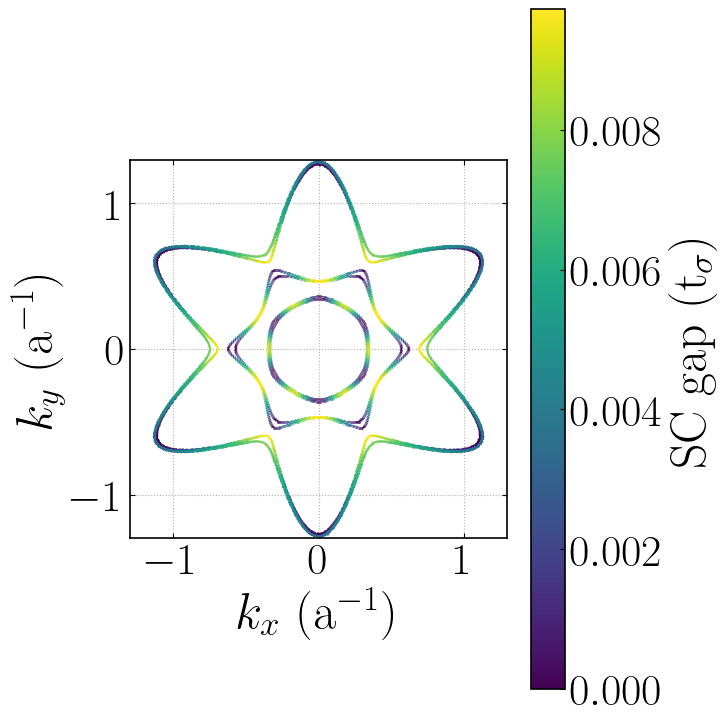

In [36]:
plot_sc_gap(bands_data)

We obtained a superconducting gap with clear directional dependence and several potential detection channels (due to several bands at the Fermi level).

Note that the gap is again symmetric with repsect tot sixfold rotations, as in case of our dispersion relation.

In [37]:
Energies, DOS = calculate_dos_superconducting_state(params_sc,
                                                    np.float64(0),
                                                    np.float64(max(bands_data[0]['ky']) * 1.05), # Allow for a slight margin
                                                    ir,
                                                    ir_coeffs,
                                                    np.float64(-2e-2),
                                                    np.float64(2e-2),
                                                    np.float64(2e-5),
                                                    np.float64(8e-5),
                                                    500)


Triangle 1 / 6


100%|██████████| 500/500 [00:28<00:00, 17.27it/s]


Triangle 2 / 6


100%|██████████| 500/500 [00:28<00:00, 17.30it/s]


Triangle 3 / 6


...

100%|██████████| 500/500 [00:28<00:00, 17.31it/s]


Triangle 5 / 6


100%|██████████| 500/500 [00:28<00:00, 17.36it/s]


Triangle 6 / 6


100%|██████████| 500/500 [00:28<00:00, 17.35it/s]


<Axes: xlabel='E ($\\text{t}_\\sigma$)', ylabel='DOS'>

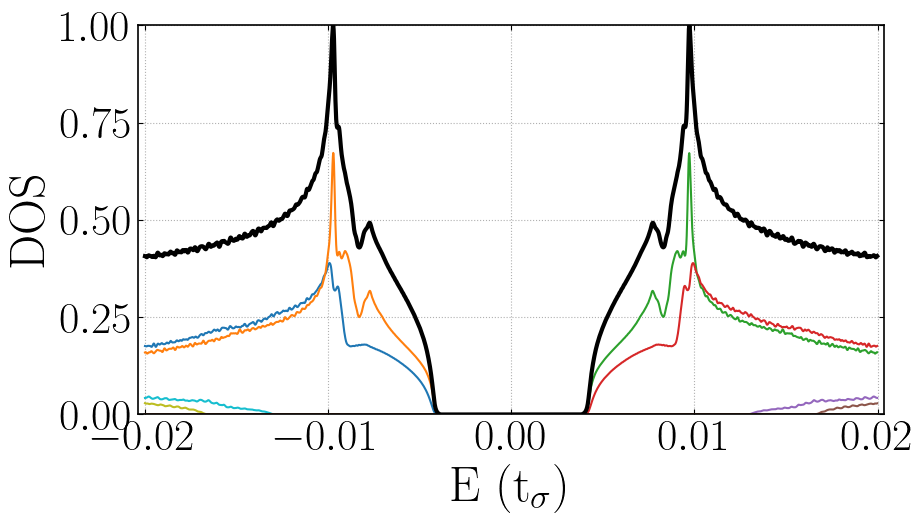

In [38]:
plot_dos(Energies, DOS)

In [39]:
# Set params for initial study
expansion_coeff = 1e-2 # [t_sigma]
n_points_gap = 500